# Skydio X10 / VT300-L — Thermal Orthomosaic Pipeline (Final)

**All confirmed fixes applied:**
- Pitch: `90 + NED_pitch` → cameratransform tilt ≈ 0° (nadir)
- Yaw: `VehicleOrientationNEDYaw + 90°` (ArcGIS confirmed)
- Roll: `interior['Roll'].median()` — stable vehicle body roll per line
- FLIP_AXIS: None
- ImageWidth/Height: original order (640/512)
- Merge: feathered blend (replaces SeaDroneLib `method='mean'` which causes blocky edges)


## Cell 0 — Imports

In [1]:
import os, glob, yaml, math, time
import numpy as np
import rasterio
import pandas as pd
from dataclasses import asdict
from seadrone.data_structures import Profile, Partition, GeoreferencePartition, MergePartition
from seadrone.processing import FlightProcessor, Sensor
from seadrone.raster import MergeUtils
from rasterio.transform import from_bounds
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling
from scipy.ndimage import distance_transform_edt
from concurrent.futures import ThreadPoolExecutor
from IPython.display import clear_output, Image as IPImage, display
print('Imports OK')

Imports OK


## Cell 1 — Paths

**Edit only this cell.**

In [2]:
PROJECT_PATH     = r"D:\Thermal_Mosaic"
BANDS_FOLDER     = os.path.join(PROJECT_PATH, "bands")
METADATA_CSV     = os.path.join(PROJECT_PATH, "metadata.csv")
SUMMARY_YML      = os.path.join(PROJECT_PATH, "summary.yml")
GEOREFERENCE_OUT = os.path.join(PROJECT_PATH, "georeferences", "bands")
MERGE_OUT        = os.path.join(PROJECT_PATH, "merges", "bands")
os.makedirs(GEOREFERENCE_OUT, exist_ok=True)
os.makedirs(MERGE_OUT,        exist_ok=True)
print(f"bands        : {BANDS_FOLDER}")
print(f"metadata     : {METADATA_CSV}")
print(f"summary      : {SUMMARY_YML}")
print(f"georeference : {GEOREFERENCE_OUT}")
print(f"merge        : {MERGE_OUT}")

bands        : D:\Thermal_Mosaic\bands
metadata     : D:\Thermal_Mosaic\metadata.csv
summary      : D:\Thermal_Mosaic\summary.yml
georeference : D:\Thermal_Mosaic\georeferences\bands
merge        : D:\Thermal_Mosaic\merges\bands


## Cell 2 — Sensor & Profile

In [3]:
SKYDIO_SENSOR = Sensor(
    name="Skydio_VT300-L", width=640, height=512,
    focal_length=13.6, sensor_x=7.68, sensor_y=6.14,
    bands_number=1, band_names=["thermal"],
)
BANDS_PROFILE = Profile(dtype='uint16', count=1,
                        height=SKYDIO_SENSOR.height,
                        width=SKYDIO_SENSOR.width, nodata=0)
FLIP_AXIS = None
print(f"Sensor  : {SKYDIO_SENSOR.name}  {SKYDIO_SENSOR.width}x{SKYDIO_SENSOR.height}")
print(f"Profile : dtype={BANDS_PROFILE.dtype}  count={BANDS_PROFILE.count}")
print(f"Flip    : {FLIP_AXIS}")

Sensor  : Skydio_VT300-L  640x512
Profile : dtype=uint16  count=1
Flip    : None


## Cell 3 — Load Metadata & Inject Columns

- `VehicleOrientationNEDYaw/Roll` already in CSV (correct vehicle body tags)
- Pitch conversion: `90 + NED_pitch` → cameratransform tilt ≈ 0° (nadir)

In [4]:
print('Loading metadata ...')
processor = FlightProcessor()
flight_metadata = processor.load_metadata(
    os.path.dirname(METADATA_CSV), os.path.basename(METADATA_CSV)
)
print(f'  {len(flight_metadata)} records')

flight_metadata['FocalLength'] = SKYDIO_SENSOR.focal_length
flight_metadata['ImageWidth']  = SKYDIO_SENSOR.width
flight_metadata['ImageHeight'] = SKYDIO_SENSOR.height
flight_metadata['SensorX']     = SKYDIO_SENSOR.sensor_x
flight_metadata['SensorY']     = SKYDIO_SENSOR.sensor_y

flight_metadata['GPSLatitude']  = flight_metadata['Latitude']
flight_metadata['GPSLongitude'] = flight_metadata['Longitude']
flight_metadata['GPSAltitude']  = flight_metadata['Altitude']

# NED pitch -89.88 → 90+(-89.88)=0.12° ≈ nadir in cameratransform convention
flight_metadata['Pitch'] = 90.0 + flight_metadata['Pitch']

flight_metadata['ID'] = (
    flight_metadata['Source']
    .str.replace(r'\.JPG$', '.tif', case=False, regex=True)
)

required = ['GPSLatitude','GPSLongitude','GPSAltitude',
            'Pitch','Roll','Yaw',
            'FocalLength','ImageWidth','ImageHeight','SensorX','SensorY']
ok = all(flight_metadata[c].notna().all() for c in required)
print(f'All required columns valid: {ok}')
r0 = flight_metadata.iloc[0]
print(f"\nRow 0 check:")
print(f"  Yaw   : {r0['Yaw']:.3f} deg  (VehicleOrientationNEDYaw)")
print(f"  Pitch : {r0['Pitch']:.3f} deg  (0=nadir)")
print(f"  Roll  : {r0['Roll']:.3f} deg  (VehicleOrientationNEDRoll)")
print(f"  ID    : {r0['ID']}")

Loading metadata ...
  173 records
All required columns valid: True

Row 0 check:
  Yaw   : 61.149 deg  (VehicleOrientationNEDYaw)
  Pitch : 0.118 deg  (0=nadir)
  Roll  : 5.463 deg  (VehicleOrientationNEDRoll)
  ID    : S1007773_R.tif


## Cell 4 — Sync Check: Bands Folder vs Metadata

In [5]:
actual_tifs = {
    os.path.basename(p)
    for p in glob.glob(os.path.join(BANDS_FOLDER, '*.tif'))
             + glob.glob(os.path.join(BANDS_FOLDER, '*.TIF'))
}
print(f'TIFFs on disk : {len(actual_tifs)}')
print(f'Rows in CSV   : {len(flight_metadata)}')
missing = set(flight_metadata['ID']) - actual_tifs
if missing:
    print(f'Dropping {len(missing)} row(s) with no matching TIFF:')
    for f in sorted(missing): print(f'  {f}')
    flight_metadata = flight_metadata[
        flight_metadata['ID'].isin(actual_tifs)
    ].reset_index(drop=True)
else:
    print('All TIFFs present ✓')
print(f'Rows ready: {len(flight_metadata)}')

TIFFs on disk : 172
Rows in CSV   : 173
Dropping 1 row(s) with no matching TIFF:
  S1008262_R.tif
Rows ready: 172


## Cell 5 — Build Flight Lines

- Fixed yaw per line: `VehicleOrientationNEDYaw + 90°` (ArcGIS confirmed)
- Fixed roll per line: `interior['Roll'].median()` (stable vehicle body roll)
- Pitch stays per-image (None) — gimbal pitch is reliable frame-by-frame

In [6]:
def circular_median(angles_deg):
    sx = sum(math.sin(math.radians(a)) for a in angles_deg)
    cx = sum(math.cos(math.radians(a)) for a in angles_deg)
    return math.degrees(math.atan2(sx, cx)) % 360

print('Building flight lines ...')
with open(SUMMARY_YML) as f:
    summary = yaml.safe_load(f)

sources       = flight_metadata['Source'].tolist()
source_to_idx = {s: i for i, s in enumerate(sources)}
flight_lines  = []

for line_name, line_cfg in summary['lines'].items():
    si_img, ei_img = line_cfg['start_img'], line_cfg['end_img']
    if si_img not in source_to_idx or ei_img not in source_to_idx:
        print(f'  Skipping {line_name}: boundary image missing'); continue
    si, ei = source_to_idx[si_img], source_to_idx[ei_img]
    n = ei - si + 1
    if n < 2:
        print(f'  Skipping {line_name}: fewer than 2 images'); continue

    segment  = flight_metadata.iloc[si:ei+1]
    interior = segment.iloc[1:-1] if n > 2 else segment
    line_yaw = circular_median(interior['Yaw'].tolist())
    corrected_yaw = (line_yaw + 90.0) % 360

    flight_lines.append({
        'start': si, 'end': ei + 1,
        'yaw':   corrected_yaw,
        'pitch': None,
        'roll':  float(interior['Roll'].median()),
        'alt':   None,
    })

print(f'Built {len(flight_lines)} flight lines ✓')
for i, fl in enumerate(flight_lines):
    n = fl['end'] - fl['start']
    print(f"  Line {i+1:>2}: rows {fl['start']:>3}-{fl['end']-1:>3}  "
          f"({n} images)  yaw={fl['yaw']:.2f}°  roll={fl['roll']:.2f}°")

Building flight lines ...
Built 15 flight lines ✓
  Line  1: rows   0- 10  (11 images)  yaw=150.87°  roll=0.19°
  Line  2: rows  11- 21  (11 images)  yaw=330.20°  roll=-2.27°
  Line  3: rows  22- 32  (11 images)  yaw=150.63°  roll=4.50°
  Line  4: rows  33- 43  (11 images)  yaw=330.17°  roll=-1.55°
  Line  5: rows  44- 54  (11 images)  yaw=151.00°  roll=3.83°
  Line  6: rows  55- 65  (11 images)  yaw=331.29°  roll=-3.08°
  Line  7: rows  66- 76  (11 images)  yaw=151.09°  roll=2.77°
  Line  8: rows  77- 88  (12 images)  yaw=330.51°  roll=-3.38°
  Line  9: rows  89-100  (12 images)  yaw=150.90°  roll=3.23°
  Line 10: rows 101-112  (12 images)  yaw=330.61°  roll=-1.52°
  Line 11: rows 113-124  (12 images)  yaw=150.99°  roll=0.54°
  Line 12: rows 125-136  (12 images)  yaw=330.82°  roll=-0.70°
  Line 13: rows 137-148  (12 images)  yaw=150.88°  roll=6.08°
  Line 14: rows 149-160  (12 images)  yaw=330.99°  roll=-1.61°
  Line 15: rows 161-171  (11 images)  yaw=150.97°  roll=0.32°


## Cell 6 — Partitions

In [7]:
partitions = {
    'all':  Partition('all',  0, None, 1),
    'even': Partition('even', 0, None, 2),
    'odd':  Partition('odd',  1, None, 2),
}
PARTITIONS_TO_GEOREFERENCE = ['all']
PARTITIONS_TO_MERGE        = ['all']
print('Partitions defined:', list(partitions.keys()))

Partitions defined: ['all', 'even', 'odd']


## Cell 7 — Georeference Thermal TIFFs

In [8]:
import shutil
shutil.rmtree(GEOREFERENCE_OUT, ignore_errors=True)
os.makedirs(GEOREFERENCE_OUT, exist_ok=True)
print('Georeferencing ...')

for pk in PARTITIONS_TO_GEOREFERENCE:
    part = partitions[pk]
    geo_partition = GeoreferencePartition(
        name=part.name, start=part.start, end=part.end,
        steps=part.steps, profile=BANDS_PROFILE
    )
    processor.georefence_bands(
        metadata=flight_metadata, partition=geo_partition,
        flight_lines=flight_lines, in_folder=BANDS_FOLDER,
        out_folder=GEOREFERENCE_OUT, flip_axis=FLIP_AXIS,
        use_metadata=True, overwrite=True,
    )

georef_tifs = sorted(glob.glob(
    os.path.join(GEOREFERENCE_OUT,'**','*.tif'), recursive=True))
print(f'Georeferenced {len(georef_tifs)} TIFFs')
if georef_tifs:
    with rasterio.open(georef_tifs[0]) as src:
        t = src.transform
        has_nan = any(math.isnan(v) for v in [t.a,t.b,t.c,t.d,t.e,t.f])
        status = '✓ Valid' if not has_nan else '✗ NaN'
        bearing = math.degrees(math.atan2(t.a, t.d)) % 360
        print(f'Spot-check {os.path.basename(georef_tifs[0])}: {status}')
        print(f'  CRS            : {src.crs}')
        print(f'  Top-edge bearing: {bearing:.1f}° (expect ~150°)')
        print(f'  Bounds         : {src.bounds}')

Georeferencing ...


  0%|                                                  | 0/172 [00:00<?, ?it/s]D:\Thermal_Mosaic\MosaicSeadron\seadronelib-venv\lib\site-packages\rasterio\__init__.py:321: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
100%|████████████████████████████████████████| 172/172 [00:12<00:00, 13.71it/s]

Georeferenced 172 TIFFs
Spot-check S1007773_R.tif: ✓ Valid
  CRS            : EPSG:4326
  Top-edge bearing: 326.2° (expect ~150°)
  Bounds         : BoundingBox(left=-87.64064762330477, bottom=33.011937777509786, right=-87.6396130389786, top=33.01286119874611)


## Cell 8 — Feathered Merge (replaces SeaDroneLib mean merge)

Uses `rasterio.warp.reproject()` to correctly handle rotated tiles,
then blends with **distance-weighted feathering** — smooth continuous
blending instead of hard rectangular seams from `method='mean'`.

**No histogram matching needed for thermal** — data is radiometrically
calibrated (absolute temperature). Adjusting brightness would corrupt
the Planck-calibrated values.

In [9]:
georef_tifs = sorted(glob.glob(
    os.path.join(GEOREFERENCE_OUT,'**','*.tif'), recursive=True))
print(f'Georeferenced TIFFs: {len(georef_tifs)}')

# ── Mosaic bounds ──────────────────────────────────────────────────────
all_left,all_bottom,all_right,all_top=[],[],[],[]
res_x=res_y=src_crs=None
for fp in georef_tifs:
    with rasterio.open(fp) as src:
        b=src.bounds
        all_left.append(b.left);all_bottom.append(b.bottom)
        all_right.append(b.right);all_top.append(b.top)
        if res_x is None:
            res_x=abs(src.transform.a);res_y=abs(src.transform.e)
            src_crs=src.crs

mosaic_left=min(all_left);mosaic_right=max(all_right)
mosaic_bottom=min(all_bottom);mosaic_top=max(all_top)
mosaic_w=int(round((mosaic_right-mosaic_left)/res_x))
mosaic_h=int(round((mosaic_top-mosaic_bottom)/res_y))
mosaic_transform=from_bounds(
    mosaic_left,mosaic_bottom,mosaic_right,mosaic_top,mosaic_w,mosaic_h)
print(f'Mosaic: {mosaic_h}x{mosaic_w}  GSD={res_x*111320*100:.1f}cm/px')

# Cache tile bounds for fast strip filtering
print('Caching tile bounds...')
tile_bounds={}
for fp in georef_tifs:
    with rasterio.open(fp) as src:
        tile_bounds[fp]=src.bounds

# ── Output file ────────────────────────────────────────────────────────
import shutil
shutil.rmtree(MERGE_OUT, ignore_errors=True)
os.makedirs(MERGE_OUT, exist_ok=True)
out_feathered=os.path.join(MERGE_OUT,'thermal_mosaic_feathered.tif')
out_profile=dict(
    driver='GTiff',dtype='uint16',count=1,
    height=mosaic_h,width=mosaic_w,
    crs=src_crs,transform=mosaic_transform,nodata=0,
    compress='LZW',tiled=True,blockxsize=512,blockysize=512
)
with rasterio.open(out_feathered,'w',**out_profile):
    pass
print(f'Output: {out_feathered}')

# ── Warp function (single-band, memory efficient) ──────────────────────
def warp_tile(fp,s0,s1):
    sh=s1-s0
    st=mosaic_top-s0*res_y;sb=mosaic_top-s1*res_y
    stf=from_bounds(mosaic_left,sb,mosaic_right,st,mosaic_w,sh)
    b=tile_bounds[fp]
    if b.top<sb or b.bottom>st or b.right<mosaic_left or b.left>mosaic_right:
        return None
    with rasterio.open(fp) as src:
        d=src.read(1).astype(np.float32)[np.newaxis]
        tf=src.transform;crs_t=src.crs
    dst=np.zeros((1,sh,mosaic_w),dtype=np.float32)
    reproject(source=d,destination=dst,
              src_transform=tf,src_crs=crs_t,
              dst_transform=stf,dst_crs=crs_t,
              resampling=Resampling.bilinear,
              src_nodata=0,dst_nodata=0)
    valid=(dst[0]>0).astype(np.float32)
    if valid.sum()==0: return None
    dist=distance_transform_edt(valid).astype(np.float32)
    wt=(dist/dist.max() if dist.max()>0 else valid)*valid
    return dst[0],wt

# ── Strip loop with live progress ─────────────────────────────────────
STRIP_H=512;N_WORKERS=4
n_strips=math.ceil(mosaic_h/STRIP_H)
print(f'Processing {n_strips} strips × {STRIP_H} rows  ({N_WORKERS} workers)\n')
t0=time.time();log=[]

with rasterio.open(out_feathered,'r+') as dst:
    for si in range(n_strips):
        s0=si*STRIP_H;s1=min(s0+STRIP_H,mosaic_h);sh=s1-s0
        stg=mosaic_top-s0*res_y;sbg=mosaic_top-s1*res_y
        strip_t=[fp for fp in georef_tifs
                 if tile_bounds[fp].top>sbg
                 and tile_bounds[fp].bottom<stg]
        if not strip_t: continue

        accum=np.zeros((sh,mosaic_w),dtype=np.float32)
        weight=np.zeros((sh,mosaic_w),dtype=np.float32)

        with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
            for res in [f.result() for f in
                        [ex.submit(warp_tile,fp,s0,s1) for fp in strip_t]]:
                if res is None: continue
                d,w=res;accum+=d*w;weight+=w

        with np.errstate(invalid='ignore',divide='ignore'):
            out=np.where(weight>0,
                         (accum/weight).clip(0,65535),0).astype(np.uint16)
        dst.write(out[np.newaxis],window=Window(0,s0,mosaic_w,sh))

        elapsed=time.time()-t0
        eta=elapsed/(si+1)*(n_strips-si-1) if si>0 else 0
        pct=100*(si+1)/n_strips
        log.append(f'Strip {si+1:>3}/{n_strips}  '
                   f'rows {s0}-{s1}  tiles={len(strip_t)}  '
                   f'{pct:.0f}%  {elapsed:.0f}s  ETA={eta:.0f}s')
        clear_output(wait=True)
        print(f'Feathered merge — {len(georef_tifs)} thermal TIFFs\n')
        for line in log[-15:]: print(line)

print(f'\nDone in {time.time()-t0:.0f}s → {out_feathered}')

Feathered merge — 172 thermal TIFFs

Strip   1/14  rows 0-512  tiles=8  7%  1s  ETA=0s
Strip   2/14  rows 512-1024  tiles=23  14%  4s  ETA=23s
Strip   3/14  rows 1024-1536  tiles=45  21%  9s  ETA=33s
Strip   4/14  rows 1536-2048  tiles=67  29%  16s  ETA=40s
Strip   5/14  rows 2048-2560  tiles=82  36%  25s  ETA=44s
Strip   6/14  rows 2560-3072  tiles=89  43%  34s  ETA=45s
Strip   7/14  rows 3072-3584  tiles=89  50%  43s  ETA=43s
Strip   8/14  rows 3584-4096  tiles=87  57%  52s  ETA=39s
Strip   9/14  rows 4096-4608  tiles=82  64%  60s  ETA=33s
Strip  10/14  rows 4608-5120  tiles=67  71%  66s  ETA=27s
Strip  11/14  rows 5120-5632  tiles=46  79%  71s  ETA=19s
Strip  12/14  rows 5632-6144  tiles=27  86%  74s  ETA=12s
Strip  13/14  rows 6144-6656  tiles=10  93%  75s  ETA=6s
Strip  14/14  rows 6656-6749  tiles=1  100%  75s  ETA=0s

Done in 75s → D:\Thermal_Mosaic\merges\bands\thermal_mosaic_feathered.tif


## Cell 9 — Quality Check

In [10]:
mosaic_files = [out_feathered]
with rasterio.open(out_feathered) as src:
    print(f'CRS    : {src.crs}')
    print(f'Shape  : {src.height} x {src.width} px')
    print(f'Dtype  : {src.dtypes[0]}')
    print(f'Bounds : {src.bounds}')
    data  = src.read(1)
    valid = data[data != 0]
    if valid.size:
        print(f'DN range : {valid.min()} – {valid.max()}')
        print(f'Coverage : {100*valid.size/data.size:.1f}%')
    else:
        print('WARNING: all pixels are nodata=0')

CRS    : EPSG:4326
Shape  : 6749 x 5803 px
Dtype  : uint16
Bounds : BoundingBox(left=-87.64212662477425, bottom=33.011937777509786, right=-87.63825777815828, top=33.01571112762708)
DN range : 21 – 36
Coverage : 51.5%


## Cell 10 — Visualise (4-panel preview)

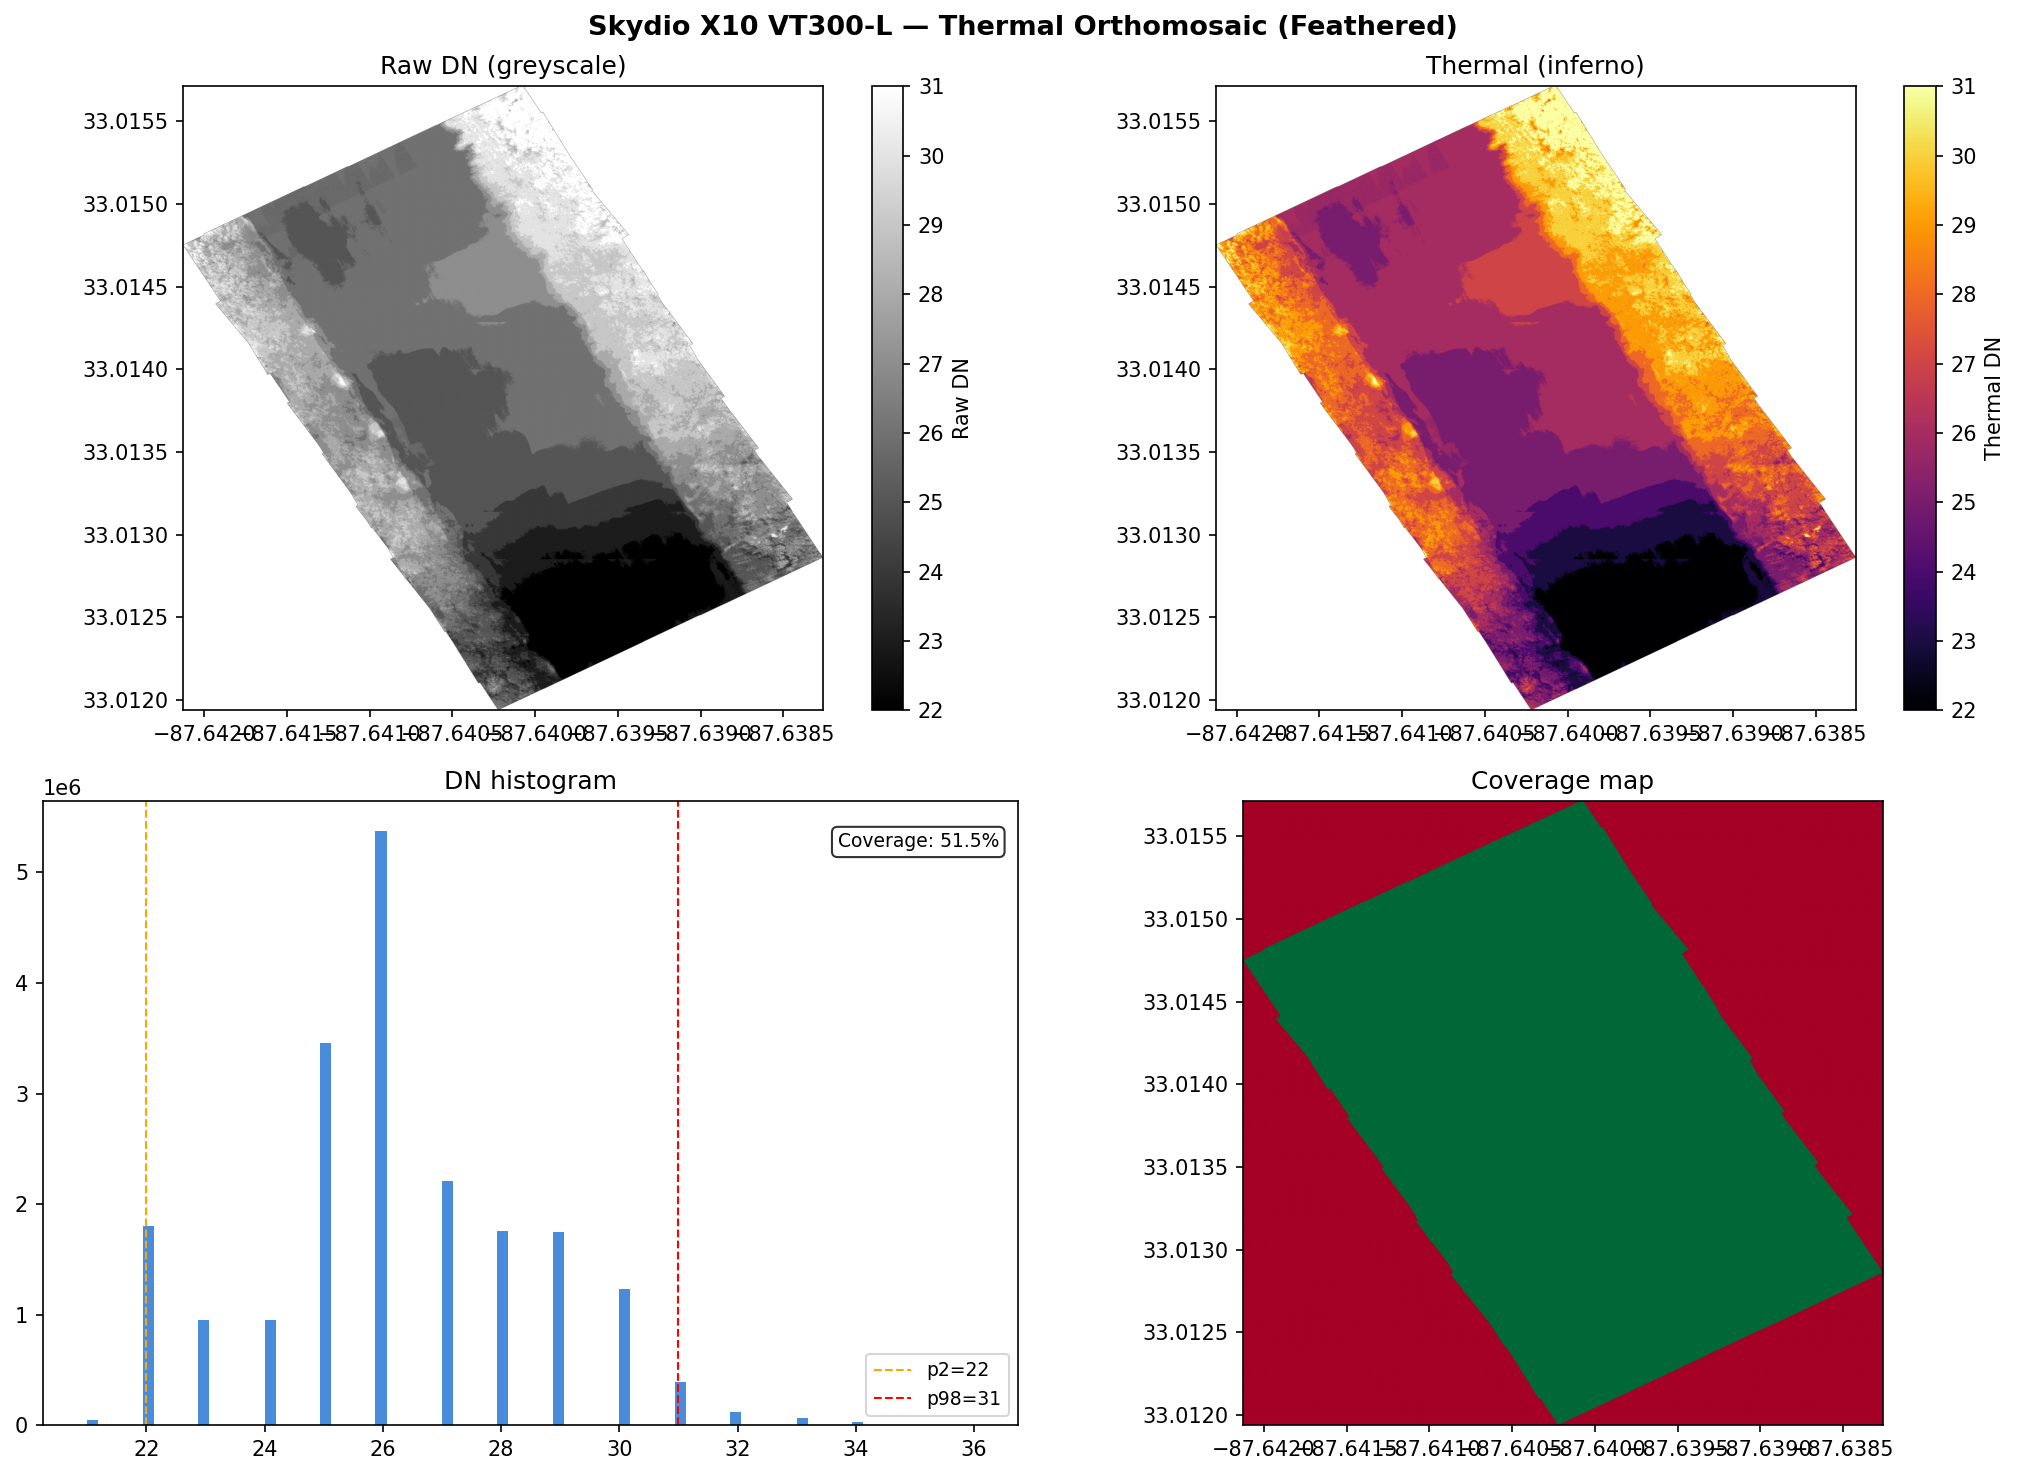

Saved → D:\Thermal_Mosaic\merges\bands\thermal_mosaic_preview.png


In [11]:
import matplotlib
if not hasattr(matplotlib.rcParams,'_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__
matplotlib.use('Agg')
import matplotlib.pyplot as plt

with rasterio.open(out_feathered) as src:
    data   = src.read(1).astype(np.float32)
    bounds = src.bounds
    profile= src.profile

mask    = (data == 0)
data_ma = np.ma.masked_where(mask, data)
valid   = data_ma.compressed()
vmin,vmax = float(np.percentile(valid,2)),float(np.percentile(valid,98))
extent  = [bounds.left,bounds.right,bounds.bottom,bounds.top]

fig, axes = plt.subplots(2,2,figsize=(14,10),dpi=120)
fig.suptitle('Skydio X10 VT300-L — Thermal Orthomosaic (Feathered)',
             fontsize=13,fontweight='bold')

ax=axes[0,0]
im=ax.imshow(data_ma,cmap='gray',vmin=vmin,vmax=vmax,
             extent=extent,aspect='equal',origin='upper')
fig.colorbar(im,ax=ax,label='Raw DN')
ax.set_title('Raw DN (greyscale)');ax.ticklabel_format(useOffset=False)

ax=axes[0,1]
im2=ax.imshow(data_ma,cmap='inferno',vmin=vmin,vmax=vmax,
              extent=extent,aspect='equal',origin='upper')
fig.colorbar(im2,ax=ax,label='Thermal DN')
ax.set_title('Thermal (inferno)');ax.ticklabel_format(useOffset=False)

ax=axes[1,0]
ax.hist(valid,bins=80,color='#2a78d6',edgecolor='none',alpha=0.85)
ax.axvline(vmin,color='orange',linestyle='--',lw=1,label=f'p2={vmin:.0f}')
ax.axvline(vmax,color='red',   linestyle='--',lw=1,label=f'p98={vmax:.0f}')
ax.set_title('DN histogram');ax.legend(fontsize=9)
ax.text(0.98,0.95,f'Coverage: {100*valid.size/data.size:.1f}%',
        transform=ax.transAxes,ha='right',va='top',fontsize=9,
        bbox=dict(boxstyle='round',fc='white',alpha=0.8))

ax=axes[1,1]
ax.imshow(np.where(mask,0,1),cmap='RdYlGn',vmin=0,vmax=1,
          extent=extent,aspect='equal',origin='upper')
ax.set_title('Coverage map');ax.ticklabel_format(useOffset=False)

plt.tight_layout()
out1=os.path.join(MERGE_OUT,'thermal_mosaic_preview.png')
fig.savefig(out1,dpi=150,bbox_inches='tight')
plt.close(fig)
display(IPImage(filename=out1))
print(f'Saved → {out1}')

## Cell 11 — Calibrated Temperature (°C)

Planck calibration using FLIR constants from APP1 EXIF tags.
**No histogram matching applied** — thermal data is radiometrically
calibrated and histogram matching would corrupt absolute temperature values.

Temperature range: 22.00 – 31.45 °C
Mean temperature : 26.39 °C


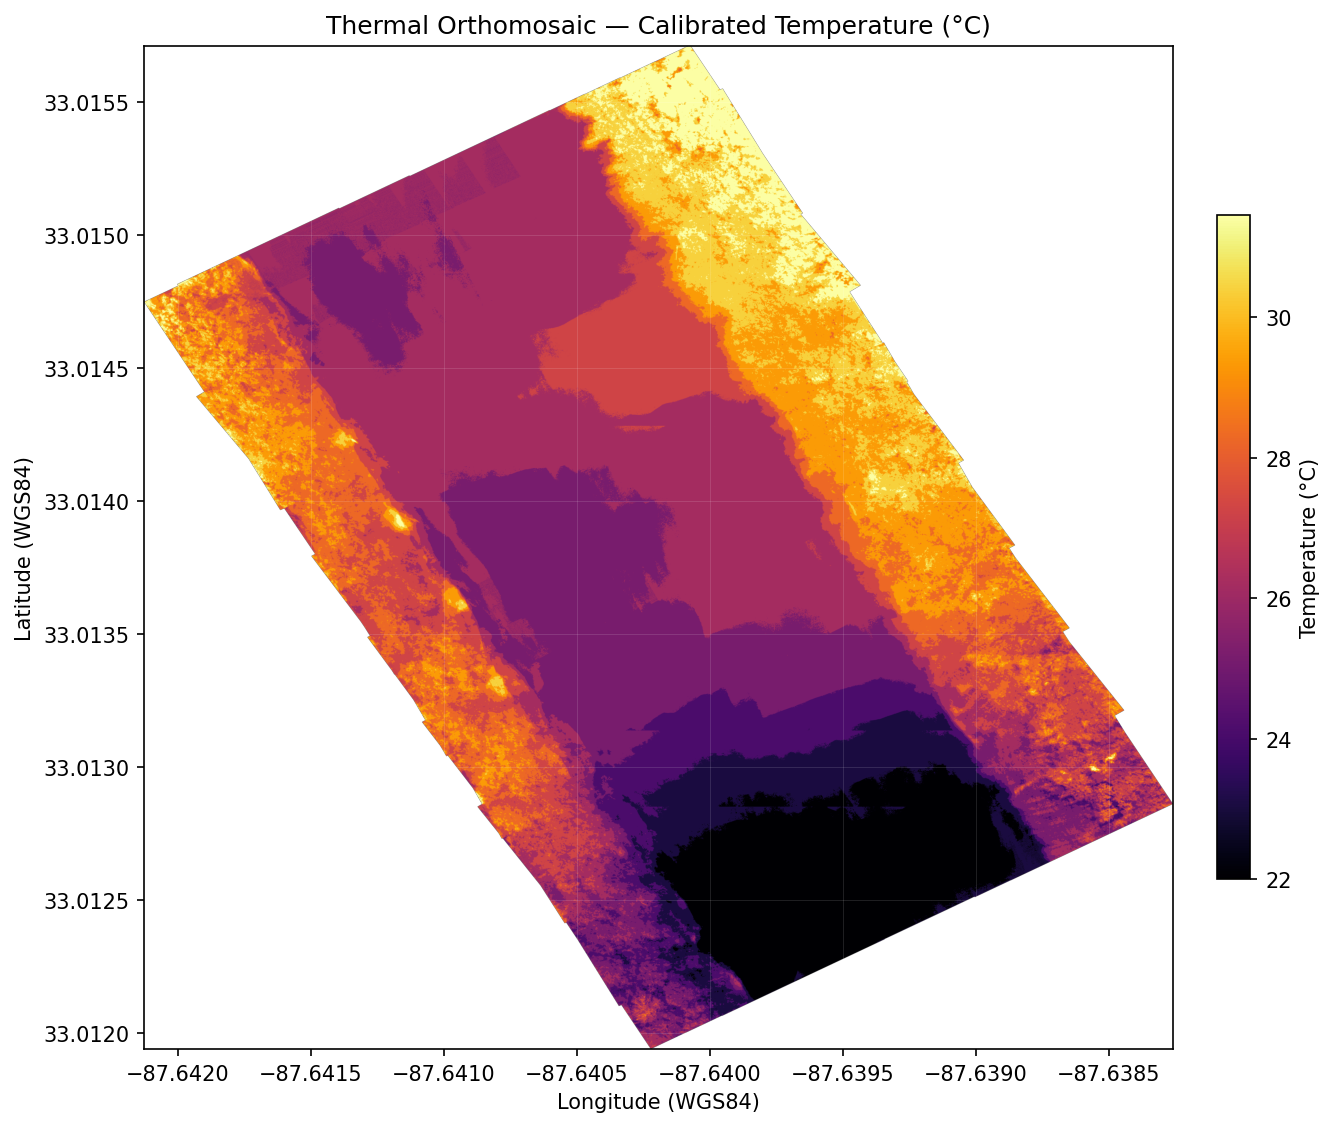

Saved → D:\Thermal_Mosaic\merges\bands\thermal_mosaic_celsius.png


In [12]:
matplotlib.use('Agg')

with rasterio.open(out_feathered) as src:
    data   = src.read(1).astype(np.float64)
    bounds = src.bounds

mask=(data==0)
R1,R2,B,F,O=2794437.5,1.0,1680.1614,1.0,-12587.0
E=0.95;T_refl=22.0

raw=np.where(mask,np.nan,data)
with np.errstate(invalid='ignore',divide='ignore'):
    rad_obj  = R1/(R2*(np.exp(B/(raw+273.15))-F))
    rad_refl = R1/(R2*(np.exp(B/(T_refl+273.15))-F))
    rad_corr = (rad_obj-(1-E)*rad_refl)/E
    rad_corr = np.where(rad_corr>0,rad_corr,np.nan)
    temp_K   = B/np.log(R1/(R2*rad_corr)+F)
    temp_C   = temp_K-273.15

temp_ma=np.ma.masked_where(mask|~np.isfinite(temp_C),temp_C)
valid_t=temp_ma.compressed()
t_p2,t_p98=float(np.percentile(valid_t,2)),float(np.percentile(valid_t,98))
print(f'Temperature range: {t_p2:.2f} – {t_p98:.2f} °C')
print(f'Mean temperature : {float(valid_t.mean()):.2f} °C')

extent=[bounds.left,bounds.right,bounds.bottom,bounds.top]
fig,ax=plt.subplots(figsize=(9,11),dpi=150)
im=ax.imshow(temp_ma,cmap='inferno',vmin=t_p2,vmax=t_p98,
             extent=extent,aspect='equal',origin='upper')
fig.colorbar(im,ax=ax,fraction=0.03,pad=0.04,label='Temperature (°C)')
ax.set_title('Thermal Orthomosaic — Calibrated Temperature (°C)',fontsize=12)
ax.set_xlabel('Longitude (WGS84)');ax.set_ylabel('Latitude (WGS84)')
ax.ticklabel_format(useOffset=False)
ax.grid(True,color='white',alpha=0.12,linewidth=0.5)
plt.tight_layout()
out3=os.path.join(MERGE_OUT,'thermal_mosaic_celsius.png')
fig.savefig(out3,bbox_inches='tight')
plt.close(fig)
display(IPImage(filename=out3))
print(f'Saved → {out3}')